# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / '/content/e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()


Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [6]:
# TODO 1: Data Profiling
print('=== 1. โครงสร้างและชนิดข้อมูล (df.info()) ===')
df.info()

print('\n=== 2. จำนวน Missing Values รายคอลัมน์ ===')
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
display(missing_summary[missing_summary['missing_count'] > 0])

print('\n=== 3. สถิติเชิงพรรณนาของข้อมูลตัวเลข ===')
display(df.describe(include='all').T)

print('\n=== 4. จำนวนแถวซ้ำทั้งแถว (Exact Duplicates) ===')
print('Exact duplicate rows:', df.duplicated().sum())

print('\n=== 5. จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ ===')
for col in ['Gender', 'Payment_Method', 'Order_Status', 'Is_Promotion', 'Province']:
    print(f"- {col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")


=== 1. โครงสร้างและชนิดข้อมูล (df.info()) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotio

,missing_count,missing_pct
Customer_Email,50,7.94
Province,12,1.90



=== 3. สถิติเชิงพรรณนาของข้อมูลตัวเลข ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,630,612,T000050,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,630,170,C0179,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,630,121,Pim Srisawat,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,580,167,jane.chaiyo179@example.com,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,10,female,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,618,8,Nakhon Ratchasima,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,630,365,2026-02-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Timestamp,630,553,2026-04-03 17:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,630,6,Food,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,630.0,NaN,NaN,NaN,3.660317,4.184784,-3.0,2.0,3.0,5.0,99.0



=== 4. จำนวนแถวซ้ำทั้งแถว (Exact Duplicates) ===
Exact duplicate rows: 18

=== 5. จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ ===
- Gender: 10 unique values -> ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']
- Payment_Method: 14 unique values -> ['Bank Transfer', 'CC', 'COD', 'Card', 'Cash on Delivery', 'Credit Card', 'PP', 'Prompt Pay', 'PromptPay', 'Transfer', 'bank_transfer', 'cash', 'credit card', 'promptpay']
- Order_Status: 7 unique values -> ['Cancel', 'Cancelled', 'Completed', 'Processing', 'Returned', 'done', 'unknown_status']
- Is_Promotion: 2 unique values -> ['N', 'Y']
- Province: 8 unique values -> ['Bangkok', 'Chanthaburi', 'Chiang Mai', 'Chonburi', 'Khon Kaen', 'Nakhon Ratchasima', 'Phuket', 'Rayong']


**ข้อสังเกตจากการทำ Data Profiling**

- ข้อมูลมีทั้งหมด 630 แถว 16 คอลัมน์ คอลัมน์ตัวเลข (`Quantity`, `Unit_Price`, `Discount_Rate`, `Transaction_Amount`) ถูกอ่านเป็นชนิดตัวเลขอยู่แล้ว แต่ควรตรวจสอบซ้ำหลังทำความสะอาด
- `Customer_Email` หายไป 50 แถว (~8%) และ `Province` หายไป 12 แถว (~1.9%) — คอลัมน์อื่นไม่มีค่าว่างในระดับ NaN แต่มีค่าว่าง/ผิดปกติแบบ "ซ่อนอยู่" ในรูปข้อความ เช่น `not_a_date`, `unknown_status`
- `Gender` มีถึง 10 รูปแบบการเขียนที่สื่อความหมายเดียวกัน (M, Male, MALE, m, male, F, Female, FEMALE, f, female)
- `Payment_Method` มี 14 รูปแบบที่ควรรวมเหลือ 5 หมวดมาตรฐาน
- `Order_Status` มีค่านอกกลุ่มมาตรฐาน เช่น `done`, `Cancel`, `unknown_status`
- `Order_Date` มีอย่างน้อย 4 รูปแบบ: YYYY-MM-DD, YYYY/MM/DD, DD/MM/YYYY หรือ MM/DD/YYYY (กำกวม), DD-MM-YYYY และค่าที่ parse ไม่ได้เลย เช่น `not_a_date`, `2026-13-05`, `31/02/2026`
- พบแถวซ้ำทั้งแถว (Exact Duplicate) 18 แถว
- `Quantity` มีค่าติดลบ (-3) และค่าผิดปกติสูงมาก (99) ซึ่งอยู่นอกช่วงธุรกิจ 1–20
- `Transaction_Amount` มีค่าติดลบ 2 แถว และมีค่าสูงผิดปกติถึง 999,999 บาท ซึ่งต้องพิจารณาร่วมกับ `Is_Promotion` ก่อนตัดสินใจว่าเป็น error หรือรายการโปรโมชันจริง


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

- Email/Province หาย 50+12 แถว (Completeness), Gender เขียนมั่ว 10 แบบ, Payment_Method อีก 10 กว่าแบบ (Consistency), Order_Date มีทั้ง parse ไม่ออกและวันที่ไม่มีจริงอย่าง "2026-13-05" (Validity), ซ้ำเป๊ะ 18 แถว (Uniqueness), Quantity ติดลบ/เกิน (-3, 99) ผิด range 1-20 (Validity), ยอดเงินพุ่งถึงเกือบล้านต้องเช็คกับ Is_Promotion ก่อน (Accuracy)


## 2) Completeness: จัดการ Missing Values

In [7]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print('Customer_Email missing:', df['Customer_Email'].isnull().sum())
print('Province missing:', df['Province'].isnull().sum())
display(df[df['Customer_Email'].isnull()][['Transaction_ID', 'Customer_ID', 'Customer_Name', 'Customer_Email']].head())
display(df[df['Province'].isnull()][['Transaction_ID', 'Customer_ID', 'Province']].head())

# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: unknown member / surrogate placeholder และสร้าง flag เพื่อย้อนตรวจสอบได้
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df.apply(
    lambda r: f"unknown_{r['Customer_ID']}@unknown.local" if pd.isnull(r['Customer_Email']) else r['Customer_Email'],
    axis=1
)

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Was_Missing'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna('Unknown')

print('\nหลังทำความสะอาด:')
print('Customer_Email missing:', df['Customer_Email'].isnull().sum(), '| flagged as was-missing:', df['Customer_Email_Was_Missing'].sum())
print('Province missing:', df['Province'].isnull().sum(), '| flagged as was-missing:', df['Province_Was_Missing'].sum())


Customer_Email missing: 50
Province missing: 12


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email
25,T000353,C0109,Jane Thongdee,NaN
30,T000205,C0134,Pim Wongsa,NaN
31,T000070,C0062,Beam Rattanakul,NaN
48,T000479,C0133,Gun Kittikul,NaN
109,T000038,C0129,Ploy Chaiyo,NaN


,Transaction_ID,Customer_ID,Province
43,T000462,C0085,NaN
44,T000441,C0016,NaN
47,T000253,C0149,NaN
56,T000498,C0149,NaN
127,T000196,C0089,NaN



หลังทำความสะอาด:
Customer_Email missing: 0 | flagged as was-missing: 50
Province missing: 0 | flagged as was-missing: 12


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**คำตอบ**

- dropna ลากทั้งแถวทิ้ง ไม่ใช่แค่ช่อง email เลยเสียยอดขายที่เกิดขึ้นจริงไปด้วย (50 แถว) ยอดรวมต่ำกว่าจริงทันที ส่วนค่าเฉลี่ยใช้กับ email ไม่ได้เพราะมันคือ identifier ไม่ใช่ตัวเลข เติมมั่วๆ เสี่ยงชนกับ email คนอื่น เลยใช้ placeholder แบบ unknown_C0103@unknown.local + flag แทน


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [8]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'm': 'M', 'male': 'M', 'M': 'M',
    'f': 'F', 'female': 'F', 'F': 'F',
}
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower().map(
    {'m': 'M', 'male': 'M', 'f': 'F', 'female': 'F'}
).fillna('Unknown')
print(df['Gender'].value_counts(dropna=False))

# TODO 3.2: Standardize Payment_Method ให้เหลือ
# Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
payment_map = {
    'cc': 'Credit Card', 'credit card': 'Credit Card', 'card': 'Credit Card',
    'pp': 'PromptPay', 'promptpay': 'PromptPay', 'prompt pay': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery', 'cash': 'Cash on Delivery',
    'transfer': 'Bank Transfer', 'bank transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer',
}
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip().str.lower().map(payment_map).fillna('Unknown')
print('\n', df['Payment_Method'].value_counts(dropna=False))

# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ระวังความกำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
# ใช้ Load_Timestamp เป็นข้อมูลประกอบ และสร้าง flag สำหรับค่าที่ต้อง fallback/impute
import re

df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'])
load_date_series = df['Load_Timestamp'].dt.date


def parse_order_date(date_str, load_date):
    s = str(date_str).strip()

    # รูปแบบ YYYY-MM-DD หรือ YYYY/MM/DD (ไม่กำกวม เพราะปีอยู่หน้าสุด)
    m = re.match(r'^(\d{4})[-/](\d{2})[-/](\d{2})$', s)
    if m:
        y, mo, d = map(int, m.groups())
        try:
            return pd.Timestamp(year=y, month=mo, day=d), 'ISO_format'
        except ValueError:
            pass  # วันที่ invalid เช่น เดือน 13 -> ไปใช้ fallback ด้านล่าง

    # รูปแบบสองหลัก-สองหลัก-สี่หลัก คั่นด้วย '-' หรือ '/' (DD/MM/YYYY หรือ MM/DD/YYYY)
    m = re.match(r'^(\d{1,2})[-/](\d{1,2})[-/](\d{4})$', s)
    if m:
        a, b, y = int(m.group(1)), int(m.group(2)), int(m.group(3))

        def safe_date(day, month, year):
            try:
                return pd.Timestamp(year=year, month=month, day=day)
            except ValueError:
                return None

        cand_dmy = safe_date(a, b, y)  # ตีความ a=วัน, b=เดือน
        cand_mdy = safe_date(b, a, y)  # ตีความ a=เดือน, b=วัน

        if a > 12 and cand_dmy is not None:
            return cand_dmy, 'DD_MM_YYYY_unambiguous'
        if b > 12 and cand_mdy is not None:
            return cand_mdy, 'MM_DD_YYYY_unambiguous'
        if a <= 12 and b <= 12:
            if cand_dmy is not None and load_date is not None and cand_dmy.date() == load_date:
                return cand_dmy, 'DD_MM_YYYY_by_load_ts'
            if cand_mdy is not None and load_date is not None and cand_mdy.date() == load_date:
                return cand_mdy, 'MM_DD_YYYY_by_load_ts'
            if cand_dmy is not None:
                return cand_dmy, 'DD_MM_YYYY_default_assumption'
        if cand_dmy is not None:
            return cand_dmy, 'DD_MM_YYYY_only_valid_option'
        if cand_mdy is not None:
            return cand_mdy, 'MM_DD_YYYY_only_valid_option'

    return None, 'UNPARSEABLE'


parsed = [parse_order_date(d, ld) for d, ld in zip(df['Order_Date'], load_date_series)]
df['Order_Date_Parsed'] = [p[0] for p in parsed]
df['Order_Date_Parse_Method'] = [p[1] for p in parsed]

# ค่าที่ parse ไม่ได้เลย -> fallback เป็นวันที่จาก Load_Timestamp ทั้งหมด
unparseable_mask = df['Order_Date_Parsed'].isnull()
df.loc[unparseable_mask, 'Order_Date_Parsed'] = pd.to_datetime(load_date_series[unparseable_mask])

# flag ว่าค่าไหน "ต้อง fallback/impute" จาก Load_Timestamp ทั้งหมด หรือใช้ Load_Timestamp ช่วยตัดสินความกำกวม
df['Order_Date_Was_Imputed'] = df['Order_Date_Parse_Method'].isin(
    ['UNPARSEABLE', 'DD_MM_YYYY_by_load_ts', 'MM_DD_YYYY_by_load_ts', 'DD_MM_YYYY_default_assumption']
)

df['Order_Date'] = df['Order_Date_Parsed'].dt.strftime('%Y-%m-%d')
df = df.drop(columns=['Order_Date_Parsed'])

print('\nวิธีที่ใช้แปลง Order_Date:')
print(df['Order_Date_Parse_Method'].value_counts())
print('\nจำนวนแถวที่ต้อง fallback/impute วันที่:', df['Order_Date_Was_Imputed'].sum())


Gender
M    344
F    286
Name: count, dtype: int64

 Payment_Method
PromptPay           173
Bank Transfer       163
Credit Card         159
Cash on Delivery    135
Name: count, dtype: int64

วิธีที่ใช้แปลง Order_Date:
Order_Date_Parse_Method
ISO_format                       409
DD_MM_YYYY_unambiguous            82
MM_DD_YYYY_unambiguous            49
DD_MM_YYYY_by_load_ts             46
MM_DD_YYYY_by_load_ts             36
UNPARSEABLE                        7
DD_MM_YYYY_default_assumption      1
Name: count, dtype: int64

จำนวนแถวที่ต้อง fallback/impute วันที่: 90


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**คำตอบ**

- 02/06/2026 — เป็นได้ทั้ง 2 มิ.ย. หรือ 6 ก.พ. ตัดสินโดยเทียบกับ Load_Timestamp ว่าใกล้วันไหนมากกว่า


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [9]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
n_exact_dup_before = df.duplicated().sum()
print('Exact duplicate rows (นับซ้ำ):', n_exact_dup_before)

rows_before = len(df)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
rows_after = len(df)
print(f'จำนวนแถวก่อนลบ: {rows_before} -> หลังลบ: {rows_after} (ลบไป {rows_before - rows_after} แถว)')

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
dup_email = df[df.duplicated('Customer_Email', keep=False) & (~df['Customer_Email_Was_Missing'])]
names_per_email = dup_email.groupby('Customer_Email')['Customer_Name'].nunique()
near_dup_emails = names_per_email[names_per_email > 1]
print('\nอีเมลที่มีชื่อลูกค้าเขียนต่างกัน (Near Duplicate):')
display(dup_email[dup_email['Customer_Email'].isin(near_dup_emails.index)]
        [['Customer_ID', 'Customer_Name', 'Customer_Email']].drop_duplicates())


Exact duplicate rows (นับซ้ำ): 18
จำนวนแถวก่อนลบ: 630 -> หลังลบ: 612 (ลบไป 18 แถว)

อีเมลที่มีชื่อลูกค้าเขียนต่างกัน (Near Duplicate):


,Customer_ID,Customer_Name,Customer_Email
95,C0047,Ploy Saelim,ploy.saelim47@example.com
96,C0047,Ploy Saelim,ploy.saelim47@example.com


### TODO 4.2 อธิบาย
เหตุใด `drop_duplicates()` เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate

**คำตอบ**

`drop_duplicates()` ทำงานโดยเปรียบเทียบค่าทุกคอลัมน์ (หรือคอลัมน์ที่ระบุ) แบบ Exact Match ตัวอักษรต่อตัวอักษรเท่านั้น หากมีลูกค้าคนเดียวกันแต่ชื่อถูกพิมพ์ต่างกันเล็กน้อย (เช่น "Thomas" กับ "Tom", ตัวสะกดต่างกัน, ช่องว่างเกิน, ตัวพิมพ์เล็ก-ใหญ่ต่างกัน) แถวเหล่านั้นจะถูกมองว่า "ไม่เหมือนกัน" ทั้งที่ในความเป็นจริงหมายถึงบุคคลเดียวกัน จึงไม่ถูกจับเป็นแถวซ้ำ

ในงานนี้จึงต้องอาศัย Secondary Key ที่มีโอกาสซ้ำน้อยกว่า เช่น `Customer_Email` หรือ `Customer_ID` เป็นตัวเชื่อมโยงแทน หากพบว่าอีเมลเดียวกันแต่ชื่อเขียนต่างกัน ก็มีความเป็นไปได้สูงว่าเป็น Near Duplicate ของลูกค้าคนเดียวกัน ในระบบจริงควรใช้เทคนิค **Fuzzy Matching** (เช่น Levenshtein distance, Jaro-Winkler, หรือไลบรารีอย่าง `recordlinkage`/`fuzzywuzzy`) เพื่อคำนวณความคล้ายของข้อความ และกำหนดค่า threshold ความคล้ายที่ยอมรับได้ เพื่อรวมลูกค้าที่เป็นบุคคลเดียวกันเข้าด้วยกัน (Entity Resolution) ก่อนโหลดเข้าสู่ Dimension Table ของ Data Warehouse


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**คำตอบ**

- ไม่ควรแก้ทุกแถว ถ้า Is_Promotion = Y ยอดที่ไม่ตรงสูตรคือของจริงจากโปรโมชัน ห้ามแก้ ส่วนที่เหลือ (N) ค่อยเช็คเป็นรายกรณีว่าเป็น error จริงไหม


## 6) Outliers: IQR และ Capping/Clipping

Q1=310.80, Q3=1023.48, IQR=712.68
Lower Bound=-758.22, Upper Bound=2092.50

จำนวน Outlier (เฉพาะที่ไม่ใช่โปรโมชัน): 19
จำนวนรายการโปรโมชันที่อยู่นอก Bound เดียวกัน (ไม่ถูกแตะต้อง): 6
จำนวนแถวที่ถูก Capping จริง: 19


/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_907/2897848208.py:39: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.ti

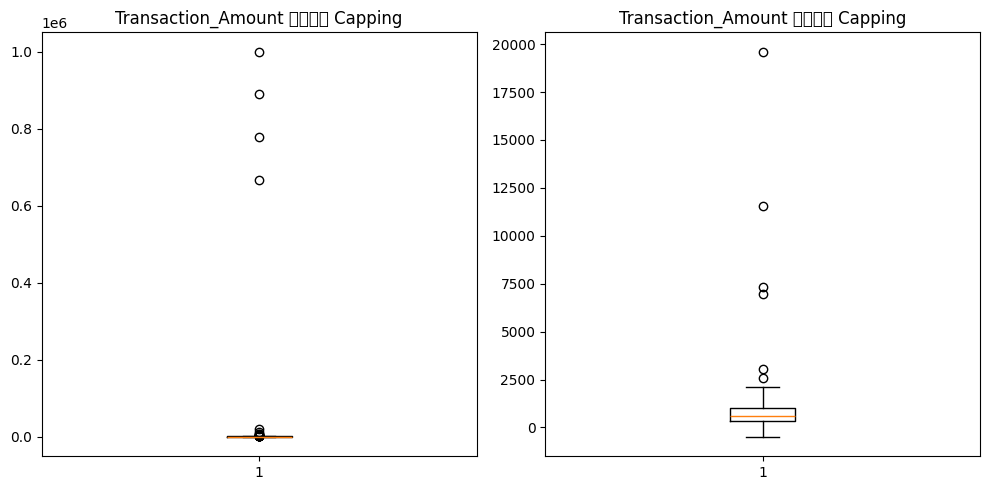

In [11]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo = df[df['Is_Promotion'] != 'Y']
Q1 = non_promo['Transaction_Amount'].quantile(0.25)
Q3 = non_promo['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Lower Bound={lower_bound:.2f}, Upper Bound={upper_bound:.2f}')

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Outlier_Flag_Before_Capping'] = (
    (df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)
) & (df['Is_Promotion'] != 'Y')
print('\nจำนวน Outlier (เฉพาะที่ไม่ใช่โปรโมชัน):', df['Outlier_Flag_Before_Capping'].sum())

promo_outlier_count = (
    (df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)
) & (df['Is_Promotion'] == 'Y')
print('จำนวนรายการโปรโมชันที่อยู่นอก Bound เดียวกัน (ไม่ถูกแตะต้อง):', promo_outlier_count.sum())

# เก็บค่าก่อน capping ไว้เพื่อเปรียบเทียบ/plot
df['Transaction_Amount_Before_Capping'] = df['Transaction_Amount'].copy()

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
mask_non_promo = df['Is_Promotion'] != 'Y'
df.loc[mask_non_promo, 'Transaction_Amount'] = df.loc[mask_non_promo, 'Transaction_Amount'].clip(
    lower=lower_bound, upper=upper_bound
)
n_capped = (df['Transaction_Amount'] != df['Transaction_Amount_Before_Capping']).sum()
print('จำนวนแถวที่ถูก Capping จริง:', n_capped)

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(df['Transaction_Amount_Before_Capping'].dropna())
axes[0].set_title('Transaction_Amount ก่อน Capping')
axes[1].boxplot(df['Transaction_Amount'].dropna())
axes[1].set_title('Transaction_Amount หลัง Capping')
plt.tight_layout()
plt.show()


### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**คำตอบ**

- เพราะ IQR จับแค่ความผิดปกติทางสถิติ ไม่รู้บริบทธุรกิจ เช่นรายการโปรโมชันในชุดนี้ที่ยอดสูง/ต่ำผิดปกติตามธรรมชาติของแคมเปญ ไม่ใช่ error เลยกันออกจากการคำนวณ bound ตั้งแต่แรก


## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [12]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ
order_date_dt = pd.to_datetime(df['Order_Date'])
df['Load_Delay_Hours'] = (df['Load_Timestamp'] - order_date_dt).dt.total_seconds() / 3600
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

n_late = df['Is_Late_Load'].sum()
pct_late = n_late / len(df) * 100
print(f'จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง: {n_late} แถว ({pct_late:.2f}%)')
print('\nสถิติ Load_Delay_Hours:')
print(df['Load_Delay_Hours'].describe())


จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง: 38 แถว (6.21%)

สถิติ Load_Delay_Hours:
count    612.000000
mean      14.346405
std       19.307341
min        1.000000
25%        5.000000
50%       10.000000
75%       16.000000
max      118.000000
Name: Load_Delay_Hours, dtype: float64


## 8) Data Quality Report และ Export

In [13]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
n_rows_before_all = len(df_raw)
n_rows_after_all = len(df)

report_data = {
    'metric': [
        'Total rows',
        'Missing Customer_Email',
        'Missing Province',
        'Exact duplicate rows',
        'Invalid / unparseable Order_Date (needed fallback or assumption)',
        'Invalid Quantity (outside 1-20)',
        'Mismatched Transaction_Amount (Accuracy_Flag, diff > 1 THB)',
        'Outliers capped (Transaction_Amount, non-promo)',
        'Late loads (> 24 hours)',
        'Invalid Order_Status (raw values outside standard set)',
    ],
    'before_cleaning': [
        n_rows_before_all,
        df_raw['Customer_Email'].isnull().sum(),
        df_raw['Province'].isnull().sum(),
        df_raw.duplicated().sum(),
        (df['Order_Date_Was_Imputed']).sum(),
        df['Quantity_Was_Invalid'].sum(),
        df['Accuracy_Flag'].sum(),
        df['Outlier_Flag_Before_Capping'].sum(),
        df['Is_Late_Load'].sum(),
        df['Order_Status_Was_Invalid'].sum(),
    ],
    'after_cleaning': [
        n_rows_after_all,
        0,  # เติมด้วย placeholder แล้ว ไม่มี NaN เหลือ
        0,  # เติมด้วย 'Unknown' แล้ว ไม่มี NaN เหลือ
        df.duplicated().sum(),
        'N/A (flag preserved for audit)',
        'N/A (flag preserved, not deleted)',
        'N/A (flag preserved, promo rows untouched)',
        (df['Transaction_Amount'] != df['Transaction_Amount_Before_Capping']).sum(),
        'N/A (informational, rows kept)',
        (~df['Order_Status'].isin(['Completed', 'Processing', 'Cancelled', 'Returned'])).sum(),
    ],
}
report = pd.DataFrame(report_data)
display(report)

# TODO 8.2: Export
export_cols_drop = ['Transaction_Amount_Before_Capping']
df_export = df.drop(columns=[c for c in export_cols_drop if c in df.columns])

df_export.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print('Exported to:', OUTPUT_DIR)
print('Clean data shape:', df_export.shape)


,metric,before_cleaning,after_cleaning
0,Total rows,630,612
1,Missing Customer_Email,50,0
2,Missing Province,12,0
3,Exact duplicate rows,18,0
4,Invalid / unparseable Order_Date (needed fallb...,88,N/A (flag preserved for audit)
5,Invalid Quantity (outside 1-20),3,"N/A (flag preserved, not deleted)"
6,"Mismatched Transaction_Amount (Accuracy_Flag, ...",50,"N/A (flag preserved, promo rows untouched)"
7,"Outliers capped (Transaction_Amount, non-promo)",19,19
8,Late loads (> 24 hours),38,"N/A (informational, rows kept)"
9,Invalid Order_Status (raw values outside stand...,5,5


Exported to: /content/outputs/student_submission
Clean data shape: (612, 28)


Reflection

1. เสี่ยงสุดคือตอน จัดการ Customer_Email ที่หาย กับตอน Capping Outlier เพราะถ้าใจร้อน dropna() หรือลบทิ้งตรงๆ จะเสียยอดขายจริงไปเลย ต้องเก็บทุกแถวไว้ใส่ flag แทน

2. ตัวที่ automate ได้เลยคือ standardize Gender/Payment_Method/Order_Status ด้วย mapping, เช็ค Quantity ให้อยู่ 1-20, คำนวณ Accuracy_Flag จาก Expected_Amount, กับ Load_Delay_Hours เพราะเป็นกฎตายตัวไม่ต้องใช้ดุลยพินิจ ต่างจากเรื่อง Outlier ของโปรโมชันที่ต้องมีคนดูด้วย

3. ตัวอย่าง Expectation:

expect_column_values_to_not_be_null — Transaction_ID, Customer_ID, Transaction_Amount
expect_column_values_to_be_between — Quantity อยู่ระหว่าง 1-20
expect_column_values_to_be_in_set — Gender/Payment_Method/Order_Status ต้องอยู่ในชุดค่าที่กำหนด
เทียบ Transaction_Amount กับ Expected_Amount ให้ต่างกันไม่เกิน threshold ที่ยอมรับได้ (เฉพาะ Is_Promotion = N)
